Text(0, 0.5, 'Latitude (deg)')

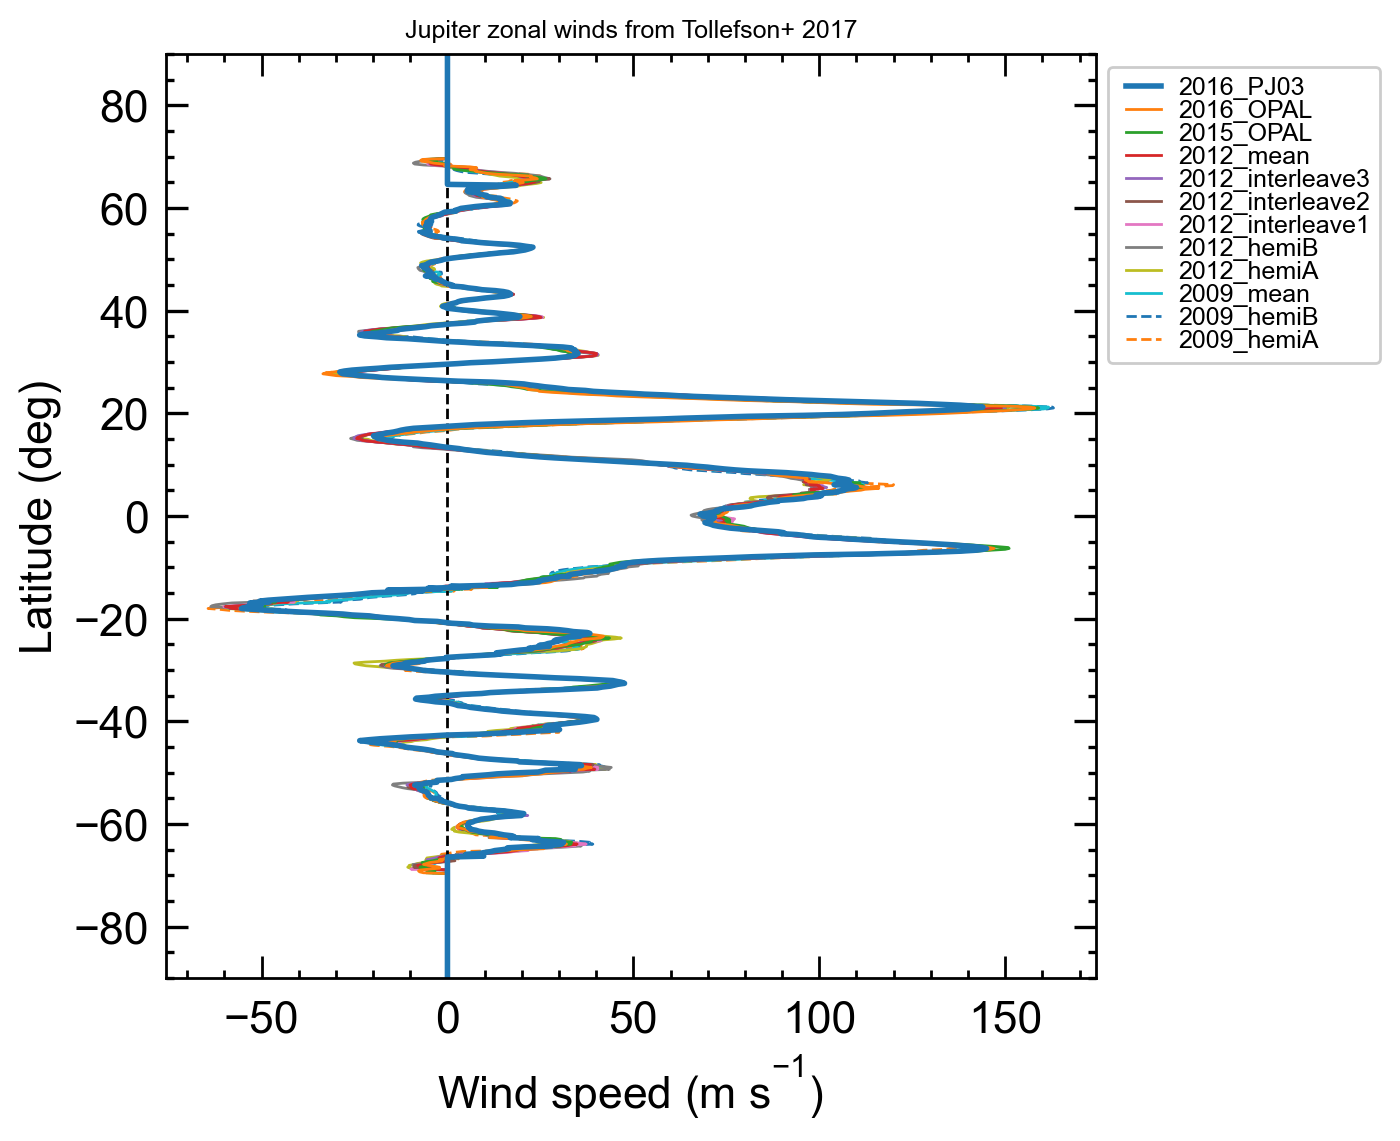

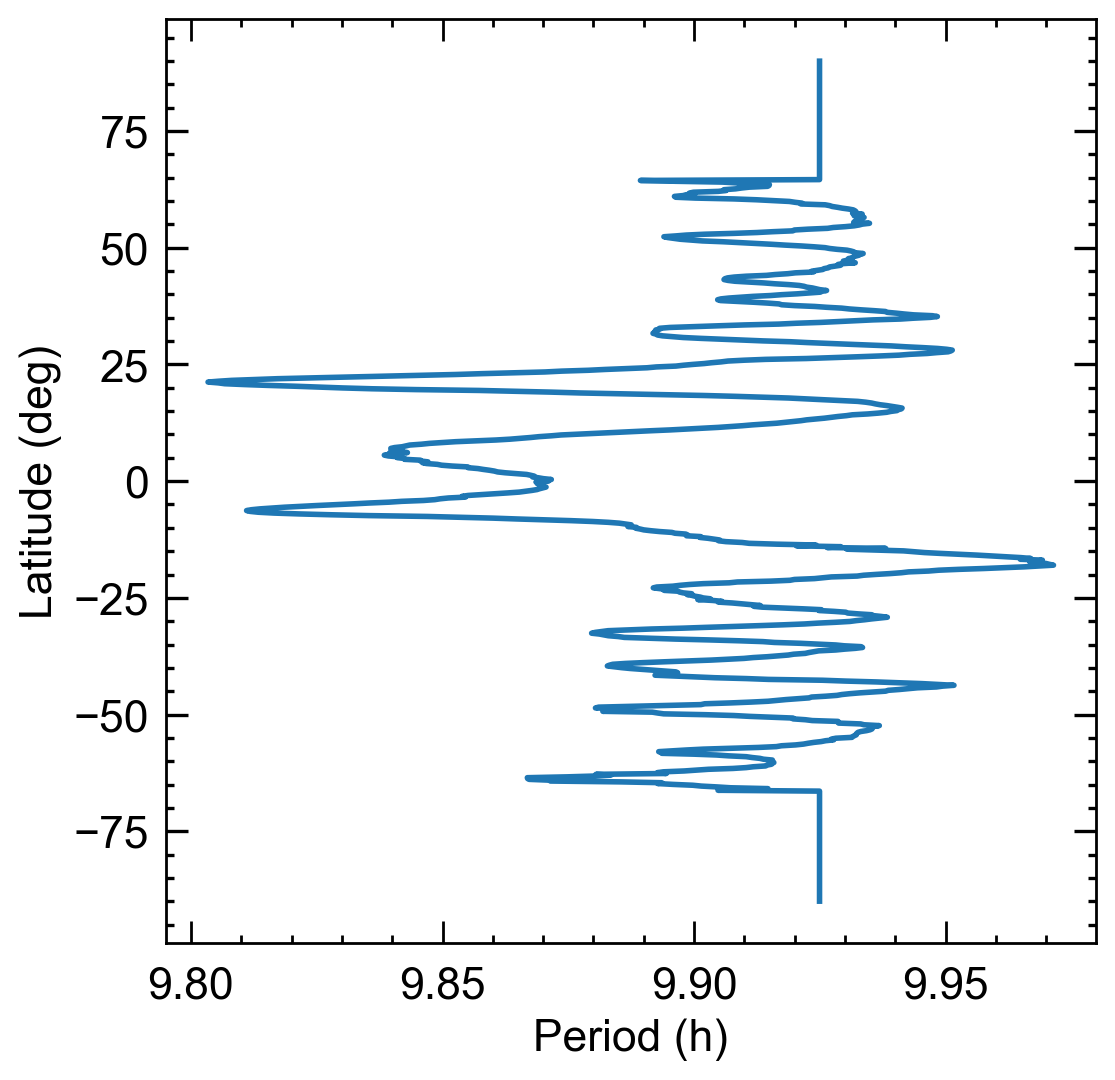

In [1]:
import matplotlib.pyplot as plt
plt.style.use(f'plots.mplstyle')
%config InlineBackend.figure_format = 'retina'

import numpy as np
from krono import const
from scipy.integrate import trapezoid
from importlib import reload

import wind_profiles; reload(wind_profiles)
import geoid; reload(geoid)

# some constants for Jupiter
r_ref = 71492e5 # reference radius for the Jn 
gm = 126686534.1 * 1e15 # conversion takes km^3 s^-2 to cm^3 s^-2
jn = 14696.5735e-6, -586.6085e-6, 34.2007e-6 # Durante et al. 2020
p_rot_h_truth = 9. + 55. / 60 + 29.71 / 3600 # e.g., Dessler 1983
periods = p_rot_h_truth + np.array([-5./60, 0, +5/60.]) # +/- 5 minutes

from occultation_data import jupiter as occultation_radii

phi = np.linspace(-np.pi / 2, np.pi / 2, 1001)
fig, ax = plt.subplots()
ax.plot(1e-2 * wind_profiles.jupiter_wind_profile_tollefson2017(phi), phi * 180 / np.pi, label='2016_PJ03')

# plot other datasets
for i_option, other_option in enumerate([\
    '2016_OPAL_201803001433999162', \
    '2015_OPAL_201803001433999161', \
    '2012_mean_201803001433999160', \
    '2012_interleave3_201803001433999159', \
    '2012_interleave2_201803001433999158', \
    '2012_interleave1_201803001433999157', \
    '2012_hemiB_201803001433999156', \
    '2012_hemiA_201803001433999155', \
    '2009_mean_201803001433999154', \
    '2009_hemiB_201803001433999153', \
    '2009_hemiA_201803001433999152']):

    # color = plt.get_cmap('Reds')(1. * i_option / 11.)
    color = f'C{i_option+1}'
    ls = '--' if i_option > 8 else '-'
    _u = wind_profiles.jupiter_wind_profile_tollefson2017(phi, option=other_option)
    ax.plot(_u * 1e-2, phi * 180 / np.pi, color=color, lw=1, label=other_option.split('_2018')[0], ls=ls, zorder=1-i_option)

ax.set_xlabel('Wind speed (m s$^{-1}$)')
ax.set_ylabel('Latitude (deg)')
ax.legend(loc=2, frameon=True, fontsize=9, bbox_to_anchor=(1, 1))
ax.set_title('Jupiter zonal winds from Tollefson+ 2017', fontsize=9)
yl = -90, 90
ax.vlines(0, *yl, color='k', linestyle='--', linewidth=1, zorder=-1)
ax.set_ylim(*yl)

omega = wind_profiles.jupiter_omega_tot_interpolant()
plt.figure()
plt.plot(np.pi * 2 / omega(phi) / 3600, phi * 180 / np.pi)
plt.xlabel('Period (h)')
plt.ylabel('Latitude (deg)')

rp   rmse_km
[6.68849564] 1.3870940519129125                    
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.3829557116152849
             x: [ 6.688e+00]
           nit: 16
          nfev: 32
 final_simplex: (array([[ 6.688e+00],
                       [ 6.688e+00]]), array([ 1.383e+00,  1.387e+00]))
rmse = 1.4 km
rmse = 9.8 km including the two outlying occultations
    period      r_pol       r_eq     h_mean
      9.84    66884.9    71537.2     -23.93
      9.92    66884.9    71537.2       3.12
     10.01    66884.9    71537.2      29.41


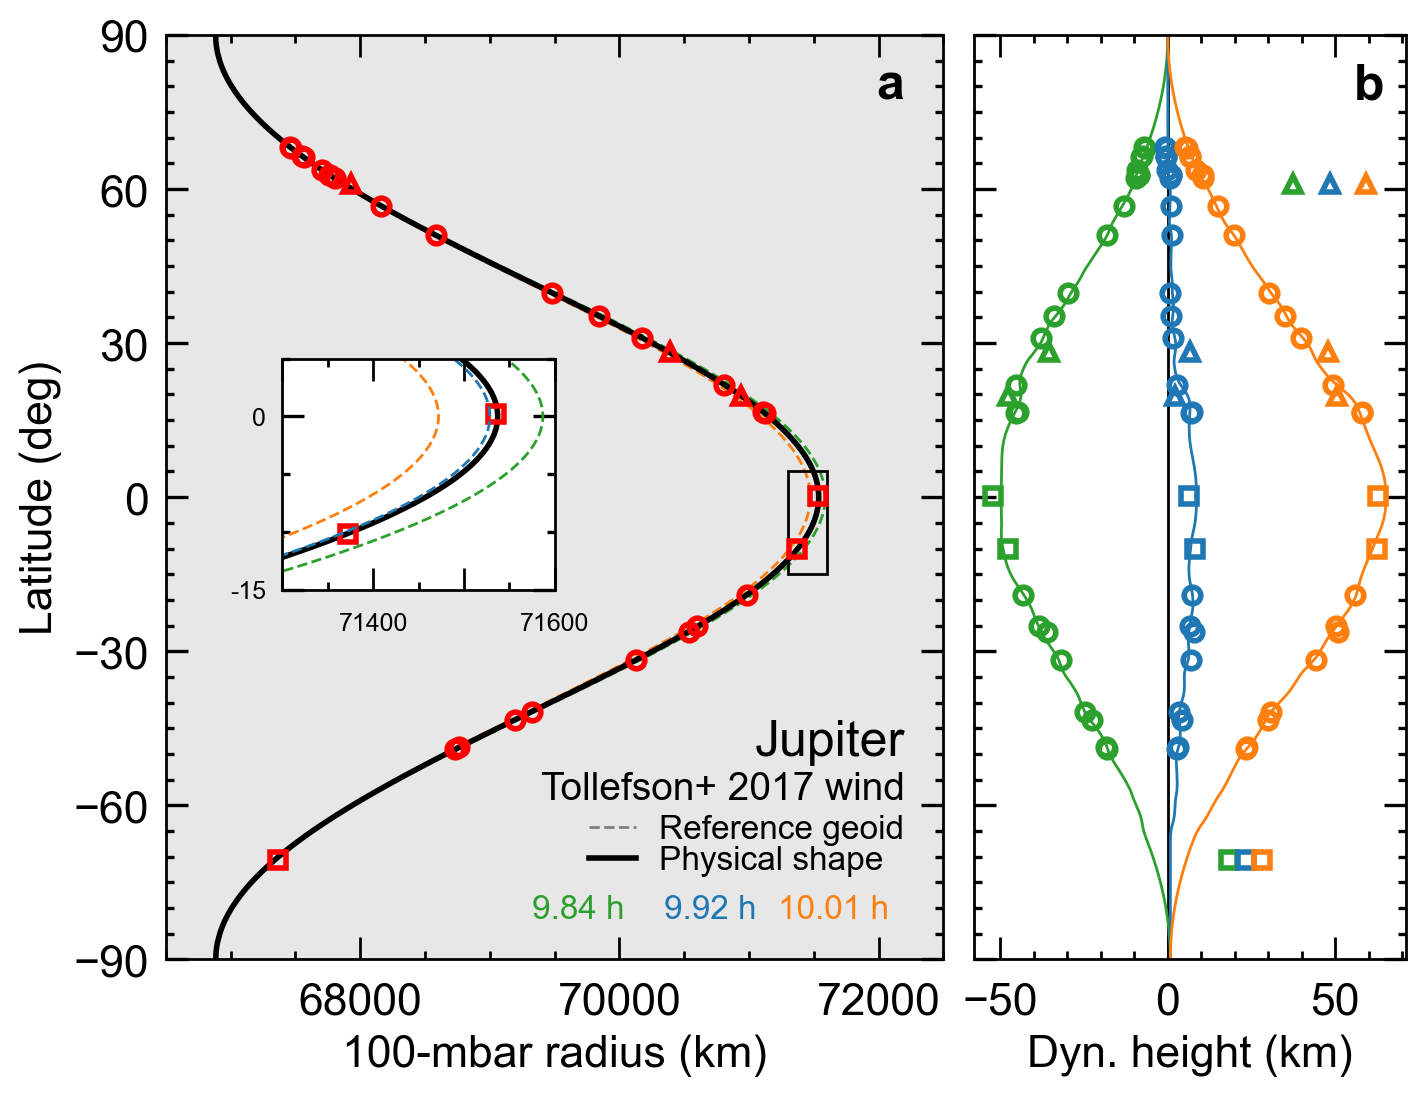

In [2]:
def shape_plot(xlim=(66500, 72500), skip_inset_eq=False, inset_xlim=(71300, 71600)):    
    from matplotlib.patches import Rectangle
    fig, ax = plt.subplots(1, 2, figsize=(8, 6), gridspec_kw={'width_ratios':(9, 5), 'wspace':0.05})
    if not skip_inset_eq: # inset near equator
        inset_xlim = inset_xlim
        ax_inset_eq = ax[0].inset_axes([0.15, 0.4, 0.35, 0.25], xlim=inset_xlim, ylim=(-15, 5), xticklabels=[], yticklabels=[])
        ax[0].add_artist(Rectangle((inset_xlim[0], -15), inset_xlim[1]-inset_xlim[0], 20, facecolor='none', edgecolor='k', lw=1, zorder=2))
        xticks = np.linspace(inset_xlim[0], inset_xlim[1], 5)
        ax_inset_eq.set_xticks(xticks, minor=True)
        ax_inset_eq.set_xticks([inset_xlim[0], inset_xlim[1]], [inset_xlim[0], inset_xlim[1]], minor=False, fontsize=9)
        ax_inset_eq.set_yticks([-15, -10, -5, 0, 5], minor=True)
        ax_inset_eq.set_yticks([-15, 0], [-15, 0], minor=False, fontsize=9)
        ax_inset_eq.set_xlim(*inset_xlim)

    yl = -90, 90 # ax[1].get_ylim()
    ax[1].vlines(0, *yl, color='k', linewidth=1, zorder=-1)
    for z in ax:
        z.set_yticks(np.linspace(-90, 90, 7), minor=False)
        z.set_yticks(np.linspace(-90, 90, 37), minor=True)
        z.set_ylim(*yl)
    ax[1].tick_params(labelleft=False)
    ax[0].set_ylabel('Latitude (deg)')
    ax[0].set_xlabel('100-mbar radius (km)')
    ax[1].set_xlabel('Dyn. height (km)')
    ax[0].set_facecolor('#e7e7e7')
    ax[0].set_xlim(*xlim)

    if skip_inset_eq:
        return ax
    else:
        return ax, ax_inset_eq

ax, ax_inset = shape_plot()
ax_inset.set_xticks(71300 + 50 * np.arange(7), minor=True)
ax_inset.set_xticks([71300, 71400, 71500, 71600], ['', 71400, '', 71600], minor=False, fontsize=9)
# ax = shape_plot(skip_inset_eq=True)

reload(geoid)
reload(wind_profiles)
colors = 'tab:green', 'tab:blue', 'tab:orange'

# omit pioneer 10 ingress and voyager 2 ingress, which cannot be fit by the adopted rotation profile?
occs_to_fit = occultation_radii.copy()
for occ in 'voyager 2 ingress', 'pioneer 10 ingress':
    occs_to_fit.pop(occ, None)

# find r_pol that minimizes rms radius error
from scipy.optimize import minimize
print('rp   rmse_km')
def rmse(x):
    r_pol = x[0] * 1e9
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation
    errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) for occ, (_lat, _r) in occs_to_fit.items()])

    _rmse = np.sqrt(np.mean(errors ** 2))
    print(f'\r{x} {_rmse}', end=' '*20)
    # print(f'{x} {_rmse}', errors)
    return _rmse
# sol = minimize(rmse, np.array([6.5]), method='Powell', bounds=[[6, 7]], tol=1e-3)
sol = minimize(rmse, np.array([6.5]), method='Nelder-Mead', bounds=[[6, 7]], options={'xatol':1e-5, 'fatol':1e0})
print()
print(sol)
print(f'rmse = {sol.fun:.1f} km')
r_pol = sol.x[0] * 1e9

# get final shape for optimized r_pol
g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

# compute full rmse including the occultations that were skipped
errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) for occ, (_lat, _r) in occultation_radii.items()])
_rmse = np.sqrt(np.mean(errors ** 2))
print(f'rmse = {_rmse:.1f} km including the two outlying occultations')

ax[0].plot(1e-5 * g.r, g.lat, 'k-')
ax_inset.plot(1e-5 * g.r, g.lat, 'k-')
for occ, (latitude, radius) in occultation_radii.items():
    marker = 'o'
    if 'voyager' in occ: marker = 's'
    if 'pioneer' in occ: marker = '^'
    ax[0]   .plot(radius, latitude, marker, mec='r', mfc='none', mew=2)
    ax_inset.plot(radius, latitude, marker, mec='r', mfc='none', mew=2)

if True:
    # save full model output to plaintext
    outfile = 'models/jupiter_model.txt'
    header  = "detailed model output for Jupiter's 100-mbar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'this is the isobaric shape model at 100 mbar assuming the zonal wind profile 2016_PJ03_201803001433999163 from Tollefson et al. (2017, Icarus 296).\n'
    header += 'see jupiter_model_reference_geoid.txt for the accompanying reference geoid rotating rigidly at System III rotation.\n'
    header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
    fmt = '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.3f', 
    names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
    for name in names:
        header += f"{name:>16} "
    data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
    np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

# reference geoids depend on rigid rotation; loop through them now
periods = p_rot_h_truth + np.array([-5./60, 0, +5/60.]) # +/- 5 minutes
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")
for ip, p_rot_h in enumerate(periods):
    
    r_pol = g.r[0]
    r_eq = g.r[len(g.mu) // 2]
    g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))
    
    color = colors[ip]

    ax[0].plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1, zorder=0)
    ax_inset.plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)

    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)

    ax[1].plot(1e-5 * h, g.lat, '-', color=color, lw=1)
    for occ, (latitude, radius) in occultation_radii.items():
        h_occ = np.interp(latitude, g.lat[::-1], radius - 1e-5 * g_ref.r[::-1])
        marker = 'o'
        if 'voyager' in occ: marker = 's'
        if 'pioneer' in occ: marker = '^'
        ax[1].plot(h_occ, latitude, marker, color=color, mfc='none', mew=2)
        # ax[1].hlines(latitude, h_occ - 15, h_occ + 15, color=color, lw=1, zorder=-1)

    ax[0].text(0.59 + 0.17 * ip, 0.07, f'{p_rot_h:.2f} h', color=color, fontsize=12, ha='right', va='top', transform=ax[0].transAxes)
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq:10.1f} {1e-5 * h_mean:10.2f}')

    if p_rot_h == p_rot_h_truth: # save this reference geoid to plaintext
        outfile = 'models/jupiter_model_reference_geoid.txt'
        header  = "detailed model output for Jupiter's 100-mbar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
        header += "this model is the reference geoid assumed to be rigidly rotating at Jupiter's nominal internal rotation period (System III) of 9h55m29.71s (e.g., Archinal et al. 2018).\n"
        header += "see jupiter_model.txt for the corresponding shape model including the effect of the latitudinally varying atmospheric rotation.\n"
        header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
        fmt = '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.5f', '%16.3f', 
        names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
        for name in names:
            header += f"{name:>16} "
        data = np.array([g_ref.mu, g_ref.phi, g_ref.lat, g_ref.planetographic_latitude, g_ref.psi, g_ref.omega, 1e-5 * g_ref.r]).T
        np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoid')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape')
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.057), fontsize=12)
ax[0].text(0.95, 0.21, 'Jupiter', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.165, 'Tollefson+ 2017 wind', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)

for iax, c in enumerate('ab'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)

plt.savefig('figures/jupiter_optimize_rpol.pdf')

# rp   rmse_km
# [6.68849564] 1.3870940519129125                    
#        message: Optimization terminated successfully.
#        success: True
#         status: 0
#            fun: 1.3829557116152849
#              x: [ 6.688e+00]
#            nit: 16
#           nfev: 32
#  final_simplex: (array([[ 6.688e+00],
#                        [ 6.688e+00]]), array([ 1.383e+00,  1.387e+00]))
# rmse = 1.4 km
# rmse = 9.8 km including the two outlying occultations
#     period      r_pol       r_eq     h_mean
#       9.84    66884.9    71537.2     -23.93
#       9.92    66884.9    71537.2       3.12
#      10.01    66884.9    71537.2      29.41


rmse = 9.5 km
    period      r_pol       r_eq     h_mean
      8.92    66886.9    71539.7    -382.93
      9.92    66886.9    71539.7       3.12
     10.92    66886.9    71539.7     275.31


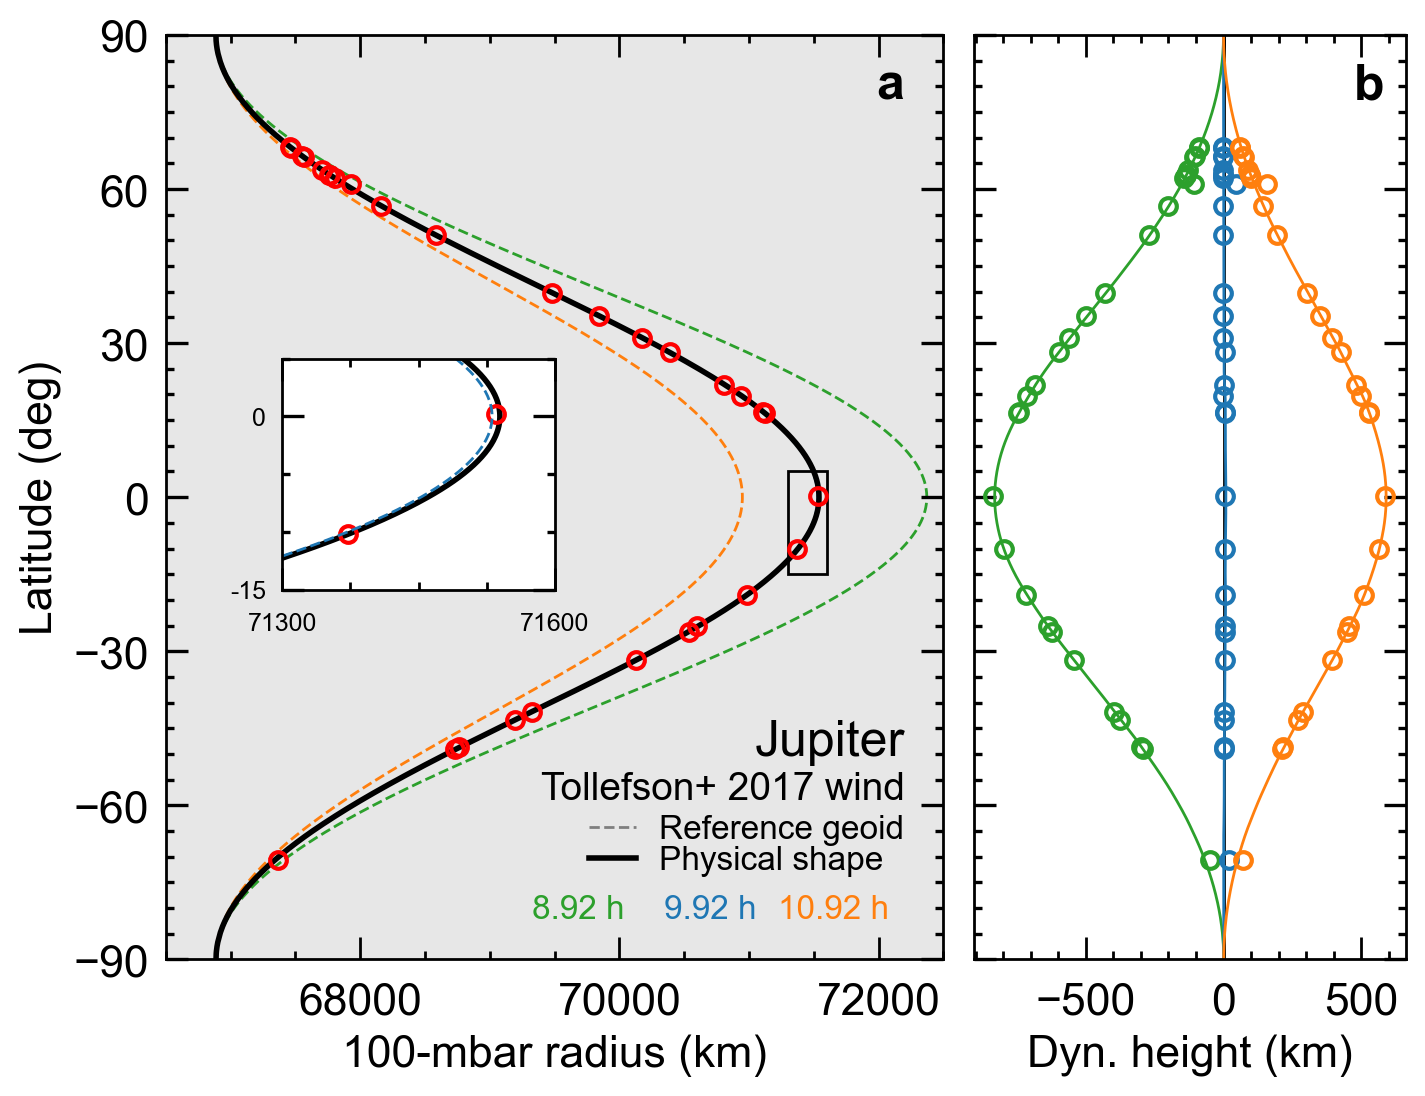

In [3]:
# same for a larger +/- 1h period span

ax, ax_inset = shape_plot(xlim=(66500, 72500), skip_inset_eq=False, inset_xlim=(71300, 71600))

reload(geoid)
reload(wind_profiles)
colors = 'tab:green', 'tab:blue', 'tab:orange'

# find r_pol that minimizes rms radius error
from scipy.optimize import minimize
def rmse(x):
    r_pol = x[0] * 1e9
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation
    squared_errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
    return np.sqrt(np.mean(squared_errors))
sol = minimize(rmse, np.array([6.5]), method='Nelder-Mead', bounds=[[6, 7]], options={'xatol':1e-5, 'fatol':1e0})
print(f'rmse = {sol.fun:.1f} km')
r_pol = sol.x[0] * 1e9

# get final shape for optimized r_pol
g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

# ax, ax_inset_eq, ax_inset_pol = plot(g, color='k', suppress_legend=True, skip_inset_pol=False, width_ratios=(9, 5), xlim_inset_pol=(24970, 24980))
ax[0].plot(1e-5 * g.r, g.lat, 'k-')
ax_inset.plot(1e-5 * g.r, g.lat, 'k-')
for occ, (latitude, radius) in occultation_radii.items():
    ax[0]   .plot(radius, latitude, 'ro', mfc='none', mew=1.5)
    ax_inset.plot(radius, latitude, 'ro', mfc='none', mew=1.5)

print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")
# periods = p_rot_h_truth + np.array([-5./60, 0, +5/60.]) # +/- 5 minutes
periods = p_rot_h_truth + np.array([-1., 0., +1.]) # +/- 1 h
# reference geoids depend on rigid rotation; loop through them now
for ip, p_rot_h in enumerate(periods):
    
    r_pol = g.r[0]
    r_eq = g.r[len(g.mu) // 2]
    g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))
    
    color = colors[ip]

    ax[0].plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1, zorder=0)
    ax_inset.plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)

    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)

    ax[1].plot(1e-5 * h, g.lat, '-', color=color, lw=1)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[1].plot(np.interp(latitude, g.lat[::-1], radius - 1e-5 * g_ref.r[::-1]), latitude, 'o', color=color, mfc='none', mew=1.5)

    ax[0].text(0.59 + 0.17 * ip, 0.07, f'{p_rot_h:.2f} h', color=color, fontsize=12, ha='right', va='top', transform=ax[0].transAxes)
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq:10.1f} {1e-5 * h_mean:10.2f}')


ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoid')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape')
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.057), fontsize=12)
ax[0].text(0.95, 0.21, 'Jupiter', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.165, 'Tollefson+ 2017 wind', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)

for iax, c in enumerate('ab'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)

plt.savefig('figures/jupiter_optimize_rpol_1h.pdf')


                                    wind     period      r_pol       r_eq     h_mean       rmse
            2016_PJ03_201803001433999163       9.92    66886.9    71539.7       3.12        9.5
            2016_OPAL_201803001433999162       9.92    66886.3    71539.7       3.68        9.4
            2015_OPAL_201803001433999161       9.92    66886.2    71539.7       3.86        9.4
            2012_mean_201803001433999160       9.92    66886.2    71539.8       3.86        9.5
     2012_interleave3_201803001433999159       9.92    66886.2    71539.7       3.79        9.5
     2012_interleave2_201803001433999158       9.92    66886.2    71539.8       3.83        9.5
     2012_interleave1_201803001433999157       9.92    66886.1    71539.8       3.97        9.5
           2012_hemiB_201803001433999156       9.92    66886.2    71539.6       3.77        9.5
           2012_hemiA_201803001433999155       9.92    66886.3    71539.7       3.74        9.4
            2009_mean_201803001433999154

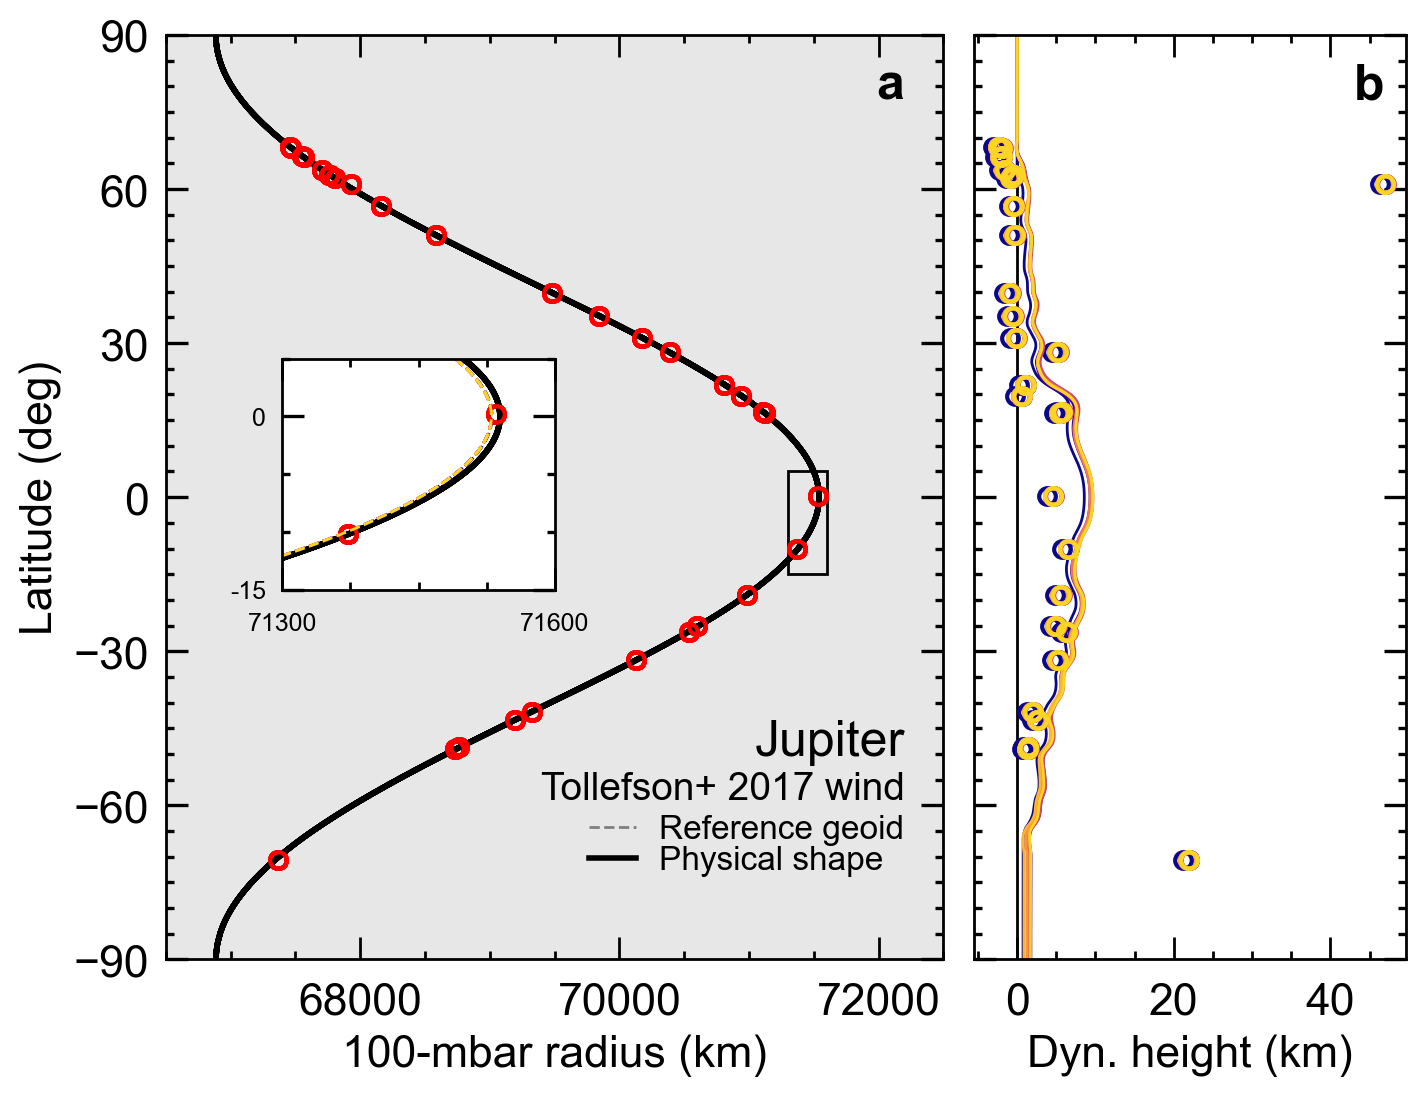

In [4]:
# vary wind profiles, should make little difference

ax, ax_inset = shape_plot()

reload(geoid)
reload(wind_profiles)
print(f"{'wind':>40} {'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10} {'rmse':>10}")

for iwind, wind_option in enumerate([ \
    '2016_PJ03_201803001433999163', \
    '2016_OPAL_201803001433999162', \
    '2015_OPAL_201803001433999161', \
    '2012_mean_201803001433999160', \
    '2012_interleave3_201803001433999159', \
    '2012_interleave2_201803001433999158', \
    '2012_interleave1_201803001433999157', \
    '2012_hemiB_201803001433999156', \
    '2012_hemiA_201803001433999155', \
    '2009_mean_201803001433999154', \
    '2009_hemiB_201803001433999153', \
    '2009_hemiA_201803001433999152']):

    color = plt.get_cmap('plasma')(iwind / 12.)

    this_omega = wind_profiles.jupiter_omega_tot_interpolant(option=wind_option)
    p_rot_h = p_rot_h_truth

    # find r_pol that minimizes rms radius error
    from scipy.optimize import minimize
    def rmse(x):
        r_pol = x[0] * 1e9
        g = geoid.geoid(r_pol, jn, r_ref, gm, omega=this_omega) # note, no presumed rigid rotation period enters the calculation
        squared_errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
        return np.sqrt(np.mean(squared_errors))
    sol = minimize(rmse, np.array([6.5]), method='Nelder-Mead', bounds=[[6, 7]], options={'xatol':1e-5, 'fatol':1e0})
    r_pol = sol.x[0] * 1e9

    # get final shape for optimized r_pol
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=this_omega)

    ax[0].plot(1e-5 * g.r, g.lat, 'k-')
    ax_inset.plot(1e-5 * g.r, g.lat, 'k-')
    for occ, (latitude, radius) in occultation_radii.items():
        ax[0]   .plot(radius, latitude, 'ro', mfc='none', mew=1.5)
        ax_inset.plot(radius, latitude, 'ro', mfc='none', mew=1.5)

    # calculate reference geoid
    r_pol = g.r[0]
    r_eq = g.r[len(g.mu) // 2]
    g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))

    ax[0].plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1, zorder=0)
    ax_inset.plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)

    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)

    ax[1].plot(1e-5 * h, g.lat, '-', color=color, lw=1)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[1].plot(np.interp(latitude, g.lat[::-1], radius - 1e-5 * g_ref.r[::-1]), latitude, 'o', color=color, mfc='none', mew=1.5)

    # ax[0].text(0.59 + 0.17 * ip, 0.07, f'{p_rot_h:.2f} h', color=color, fontsize=12, ha='right', va='top', transform=ax[0].transAxes)
    print(f'{wind_option:>40} {p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq:10.1f} {1e-5 * h_mean:10.2f} {sol.fun:10.1f}')


ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoid')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape')
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.057), fontsize=12)
ax[0].text(0.95, 0.21, 'Jupiter', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.165, 'Tollefson+ 2017 wind', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)

for iax, c in enumerate('ab'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)

# plt.savefig('figures/jupiter_optimize_rpol_various_wind_profiles.pdf')


In [5]:
deg_per_hour = 870.536 / 24 # checking rotation period directly from Archinal et al. (2018) IAU report, Table 1
hms = lambda period_h: f'{int(period_h)}h {int(period_h * 60 % 60)}m {period_h * 3600 % 60:.2f}s'
print(hms(360 / deg_per_hour))

9h 55m 29.71s
